In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

hourly = pd.read_csv(PROCESSED_DIR / "hourly_pickups.csv", parse_dates=["hour"])  # from data_cleaning notebook
weather = pd.read_csv(PROCESSED_DIR / "weather_clean.csv", parse_dates=["hour"])
stations = pd.read_csv(PROCESSED_DIR / "stations_clean.csv")

print(f"Hourly pickups: {len(hourly):,} rows ({hourly['station_id'].nunique()} stations, {hourly['hour'].nunique():,} hours)")
print(f"Weather: {len(weather):,} rows")
print(f"Stations: {len(stations)} rows")

Hourly pickups: 7,142,784 rows (979 stations, 7,296 hours)
Weather: 7,296 rows
Stations: 1022 rows


Merging weather data cause every station in the same hour gets the same weather since it's city-level data.

In [25]:
df = hourly.merge(weather, on="hour", how="left")

print(f"After weather merge: {len(df):,} rows")
print(f"Null check:\n{df.isnull().sum()}")
df.head()

After weather merge: 7,142,784 rows
Null check:
station_id          0
hour                0
pickups             0
temperature_c       0
precipitation_mm    0
wind_speed_kmh      0
weather_code        0
dtype: int64


,station_id,hour,pickups,temperature_c,precipitation_mm,wind_speed_kmh,weather_code
0,7000,2025-01-01 00:00:00,0,3.7,0.0,14.9,3
1,7000,2025-01-01 01:00:00,0,3.3,0.0,14.0,3
2,7000,2025-01-01 02:00:00,1,2.8,0.0,15.2,3
3,7000,2025-01-01 03:00:00,1,2.2,0.0,17.9,3
4,7000,2025-01-01 04:00:00,0,2.0,0.0,19.6,3


### Clustering stations with K-means
Group all stations into geographic clusters using K-means on lat/lon

In [26]:
station_coords = stations[["station_id", "lat", "lon", "capacity"]].copy()  # grab coordinates and capacity
print(f"Stations with metadata: {len(station_coords)}")
print(f"Lat range: {station_coords['lat'].min():.4f} to {station_coords['lat'].max():.4f}")
print(f"Lon range: {station_coords['lon'].min():.4f} to {station_coords['lon'].max():.4f}")

Stations with metadata: 1022
Lat range: 43.5881 to 43.8126
Lon range: -79.6035 to -79.1232


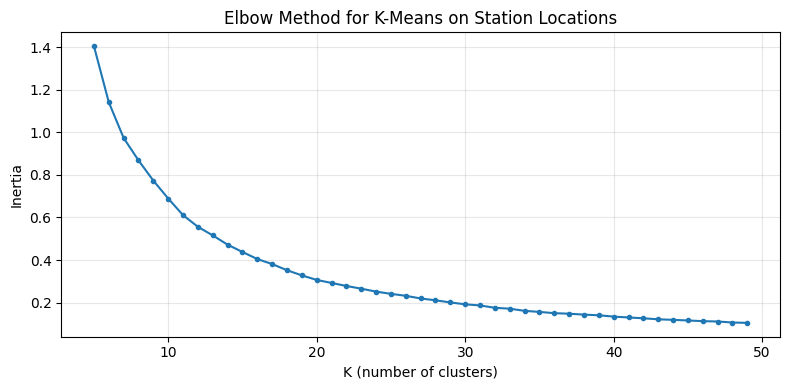

In [27]:
X = station_coords[["lat", "lon"]].values  # features for clustering

K_range = range(5, 50)  # test K from 5 to x
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o", markersize=3)
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means on Station Locations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
OPTIMAL_K = 10

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
station_coords["cluster_id"] = kmeans.fit_predict(X)

print(f"Assigned {len(station_coords)} stations to {OPTIMAL_K} clusters")
print(f"\nStations per cluster:")
print(station_coords["cluster_id"].value_counts().sort_index().describe())

Assigned 1022 stations to 10 clusters

Stations per cluster:
count     10.000000
mean     102.200000
std       80.864496
min       37.000000
25%       58.000000
50%       71.500000
75%      121.000000
max      309.000000
Name: count, dtype: float64


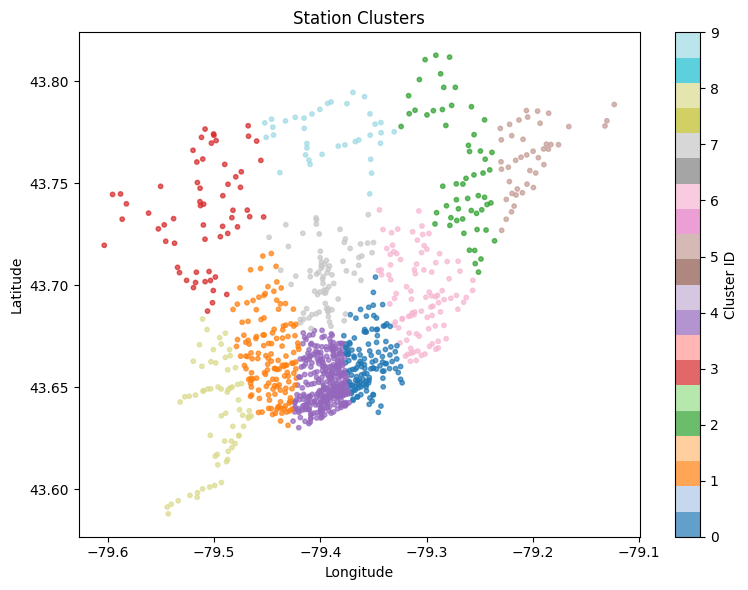

In [29]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(station_coords["lon"], station_coords["lat"],
                      c=station_coords["cluster_id"], cmap="tab20", s=10, alpha=0.7)
plt.colorbar(scatter, label="Cluster ID")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Station Clusters")
plt.tight_layout()
plt.show()

In [30]:
cluster_capacity = station_coords.groupby("cluster_id")["capacity"].sum().rename("cluster_capacity")  # total capacity per cluster
print(f"Cluster capacities:\n{cluster_capacity.describe()}")

Cluster capacities:
count      10.00000
mean     1936.20000
std      1830.04255
min       629.00000
25%       836.75000
50%      1360.50000
75%      2360.25000
max      6709.00000
Name: cluster_capacity, dtype: float64


### Aggregating to cluster-hour level
Sum pickups from all stations in each cluster per hour

In [31]:
station_to_cluster = station_coords[["station_id", "cluster_id"]]
df = df.merge(station_to_cluster, on="station_id", how="inner")  # attach cluster labels
print(f"Rows after cluster merge: {len(df):,} (dropped stations without metadata)")

df = df.groupby(["cluster_id", "hour"]).agg(  # aggregate to cluster-hour level
    pickups=("pickups", "sum"),
    temperature_c=("temperature_c", "first"),
    precipitation_mm=("precipitation_mm", "first"),
    wind_speed_kmh=("wind_speed_kmh", "first"),
    weather_code=("weather_code", "first"),
).reset_index()

df = df.merge(cluster_capacity, on="cluster_id", how="left")  # add cluster capacity

print(f"Cluster-hour rows: {len(df):,} ({df['cluster_id'].nunique()} clusters x {df['hour'].nunique():,} hours)")
print(f"Zero-pickup rows: {(df['pickups'] == 0).mean():.1%}")
print(f"Pickups mean: {df['pickups'].mean():.2f}")

Rows after cluster merge: 7,142,784 (dropped stations without metadata)
Cluster-hour rows: 72,960 (10 clusters x 7,296 hours)
Zero-pickup rows: 24.1%
Pickups mean: 91.97


### Quick check: zero-inflation after clustering
How much did clustering help with the zero-demand problem?

In [32]:
total_rows = len(df)
zero_rows = (df["pickups"] == 0).sum()
print(f"Total cluster-hour rows: {total_rows:,}")
print(f"Zero-pickup rows: {zero_rows:,} ({zero_rows/total_rows:.1%})")
print(f"Non-zero rows: {total_rows - zero_rows:,} ({(total_rows - zero_rows)/total_rows:.1%})")
print(f"\nFor comparison, station-level had 69.6% zeros")
print(f"Clustering reduced zeros to {zero_rows/total_rows:.1%}")
print(f"\nPickup distribution across clusters:")
print(df["pickups"].describe())

Total cluster-hour rows: 72,960
Zero-pickup rows: 17,608 (24.1%)
Non-zero rows: 55,352 (75.9%)

For comparison, station-level had 69.6% zeros
Clustering reduced zeros to 24.1%

Pickup distribution across clusters:
count    72960.000000
mean        91.967873
std        268.849327
min          0.000000
25%          1.000000
50%          6.000000
75%         46.000000
max       3688.000000
Name: pickups, dtype: float64


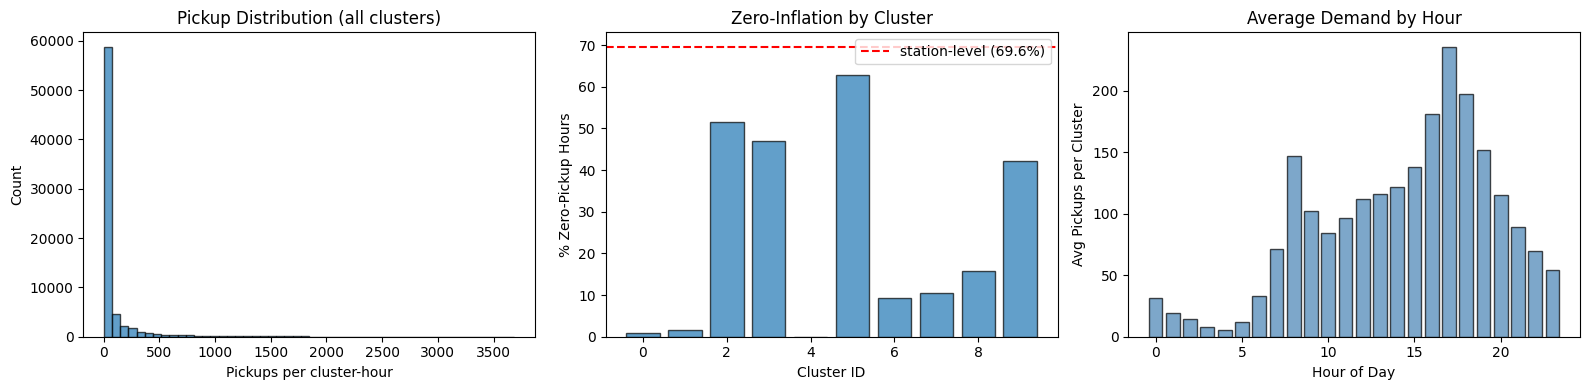

Zero-inflation per cluster: min=0.0%, max=62.8%, mean=24.1%


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["pickups"], bins=50, edgecolor="black", alpha=0.7)  # overall distribution
axes[0].set_xlabel("Pickups per cluster-hour")
axes[0].set_ylabel("Count")
axes[0].set_title("Pickup Distribution (all clusters)")

zeros_per_cluster = df.groupby("cluster_id")["pickups"].apply(lambda x: (x == 0).mean()) * 100  # zeros by cluster
axes[1].bar(zeros_per_cluster.index, zeros_per_cluster.values, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("% Zero-Pickup Hours")
axes[1].set_title("Zero-Inflation by Cluster")
axes[1].axhline(69.6, color="red", linestyle="--", label="station-level (69.6%)")
axes[1].legend()

hourly_avg = df.groupby(df["hour"].dt.hour)["pickups"].mean()  # hourly demand pattern
axes[2].bar(hourly_avg.index, hourly_avg.values, edgecolor="black", alpha=0.7, color="steelblue")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Avg Pickups per Cluster")
axes[2].set_title("Average Demand by Hour")

plt.tight_layout()
plt.show()

print(f"Zero-inflation per cluster: min={zeros_per_cluster.min():.1f}%, max={zeros_per_cluster.max():.1f}%, mean={zeros_per_cluster.mean():.1f}%")

Extract time-based features from the hour column for temporal features

In [10]:
df["hour_of_day"] = df["hour"].dt.hour
df["day_of_week"] = df["hour"].dt.dayofweek  # 0=Mon, 6=Sun
df["month"] = df["hour"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["is_rush_hour"] = (  # weekday 7-9 AM or 4-7 PM
    (df["is_weekend"] == 0) &
    (
        df["hour_of_day"].between(7, 9) |
        df["hour_of_day"].between(16, 18)
    )
).astype(int)

ontario_holidays_2025 = pd.to_datetime([  # Ontario statutory holidays
    "2025-01-01", "2025-02-17", "2025-04-18", "2025-05-19",
    "2025-07-01", "2025-08-04", "2025-09-01", "2025-10-13",
])
df["is_holiday"] = df["hour"].dt.normalize().isin(ontario_holidays_2025).astype(int)

print("Temporal features added:")
print(f"  hour_of_day: {df['hour_of_day'].min()} to {df['hour_of_day'].max()}")
print(f"  day_of_week: {df['day_of_week'].min()} to {df['day_of_week'].max()}")
print(f"  month: {df['month'].min()} to {df['month'].max()}")
print(f"  is_weekend: {df['is_weekend'].mean():.1%} of rows")
print(f"  is_rush_hour: {df['is_rush_hour'].mean():.1%} of rows")
print(f"  is_holiday: {df['is_holiday'].sum():,} rows ({df['is_holiday'].mean():.2%})")

Temporal features added:
  hour_of_day: 0 to 23
  day_of_week: 0 to 6
  month: 1 to 10
  is_weekend: 28.3% of rows
  is_rush_hour: 17.9% of rows
  is_holiday: 2,880 rows (2.63%)


Add a binary rain flag from precipitation for weather features

In [11]:
df["is_rainy"] = (df["precipitation_mm"] > 0).astype(int)

print(f"Rainy hours: {df['is_rainy'].mean():.1%} of rows")
print(f"Precipitation when rainy, mean: {df.loc[df['is_rainy'] == 1, 'precipitation_mm'].mean():.2f} mm")

Rainy hours: 13.6% of rows
Precipitation when rainy, mean: 0.70 mm


Compute lag and rolling-mean features on the full continuous time series before splitting

In [12]:
df = df.sort_values(["cluster_id", "hour"]).reset_index(drop=True)  # sort by cluster and time

df["lag_1h"] = df.groupby("cluster_id")["pickups"].shift(1)  # point lags per cluster
df["lag_24h"] = df.groupby("cluster_id")["pickups"].shift(24)
df["lag_168h"] = df.groupby("cluster_id")["pickups"].shift(168)

df["rolling_24h_mean"] = df.groupby("cluster_id")["pickups"].transform(  # rolling means per cluster
    lambda x: x.shift(1).rolling(24, min_periods=1).mean()
)
df["rolling_168h_mean"] = df.groupby("cluster_id")["pickups"].transform(
    lambda x: x.shift(1).rolling(168, min_periods=1).mean()
)

lag_cols = ["lag_1h", "lag_24h", "lag_168h", "rolling_24h_mean", "rolling_168h_mean"]
df[lag_cols] = df[lag_cols].fillna(0)  # fill NaN lags with 0 (first hours of each cluster)

print("Lag features added:")
for col in lag_cols:
    print(f"  {col}: nulls={df[col].isnull().sum()}, mean={df[col].mean():.3f}")
print(f"\nTotal columns: {len(df.columns)}")

Lag features added:
  lag_1h: nulls=0, mean=61.297
  lag_24h: nulls=0, mean=61.128
  lag_168h: nulls=0, mean=59.913
  rolling_24h_mean: nulls=0, mean=61.201
  rolling_168h_mean: nulls=0, mean=60.766

Total columns: 20


### Train/test split
Split by day of month: days 1 to 20 go to train, days 21+ go to test, both sets cover the 10 months

In [13]:
df["day_of_month"] = df["hour"].dt.day

train = df[df["day_of_month"] <= 20].copy()  # days 1-20 = train
test = df[df["day_of_month"] > 20].copy()  # days 21+ = test

train.drop(columns=["day_of_month"], inplace=True)
test.drop(columns=["day_of_month"], inplace=True)
df.drop(columns=["day_of_month"], inplace=True)

print(f"Train: {len(train):,} rows ({len(train)/len(df):.1%}), days 1 to 20 of each month")
print(f"Test:  {len(test):,} rows ({len(test)/len(df):.1%}), days 21+ of each month")
print(f"\nTrain months: {sorted(train['month'].unique())}")
print(f"Test months:  {sorted(test['month'].unique())}")
print(f"\nTrain pickups mean: {train['pickups'].mean():.3f}")
print(f"Test pickups mean:  {test['pickups'].mean():.3f}")
print(f"Train zero %: {(train['pickups'] == 0).mean():.1%}")
print(f"Test zero %:  {(test['pickups'] == 0).mean():.1%}")

Train: 72,000 rows (65.8%), days 1 to 20 of each month
Test:  37,440 rows (34.2%), days 21+ of each month

Train months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]
Test months:  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]

Train pickups mean: 61.295
Test pickups mean:  61.345
Train zero %: 31.3%
Test zero %:  30.8%


Cluster average pickups gotten from training data only to prevent data leakage.

In [14]:
cluster_avg = train.groupby("cluster_id")["pickups"].mean().rename("cluster_avg_pickups")  # from train only

train = train.merge(cluster_avg, on="cluster_id", how="left")
test = test.merge(cluster_avg, on="cluster_id", how="left")

print("cluster_avg_pickups (computed from train only):")
print(f"  Train nulls: {train['cluster_avg_pickups'].isnull().sum()}")
print(f"  Test nulls:  {test['cluster_avg_pickups'].isnull().sum()}")
print(f"  Range: {train['cluster_avg_pickups'].min():.3f} to {train['cluster_avg_pickups'].max():.3f}")

cluster_avg_pickups (computed from train only):
  Train nulls: 0
  Test nulls:  0
  Range: 0.298 to 524.689


## Feature groups and final check

In [15]:
CLUSTER_FEATURES = ["cluster_capacity", "cluster_avg_pickups"]
TEMPORAL_FEATURES = ["hour_of_day", "day_of_week", "month", "is_weekend", "is_rush_hour", "is_holiday"]
WEATHER_FEATURES = ["temperature_c", "precipitation_mm", "wind_speed_kmh", "is_rainy"]
LAG_FEATURES = ["lag_1h", "lag_24h", "lag_168h", "rolling_24h_mean", "rolling_168h_mean"]
ALL_FEATURES = CLUSTER_FEATURES + TEMPORAL_FEATURES + WEATHER_FEATURES + LAG_FEATURES
TARGET = "pickups"

print("Feature groups:")
print(f"  Cluster:  {CLUSTER_FEATURES}")
print(f"  Temporal: {TEMPORAL_FEATURES}")
print(f"  Weather:  {WEATHER_FEATURES}")
print(f"  Lag:      {LAG_FEATURES}")
print(f"\n  Total features: {len(ALL_FEATURES)}")
print(f"  Target: {TARGET}")

print(f"\nTrain: {len(train):,} rows x {len(train.columns)} columns")
print(f"Test:  {len(test):,} rows x {len(test.columns)} columns")
print(f"\nColumns: {list(train.columns)}")
print(f"\nNull counts:\n{train.isnull().sum().to_string()}")

Feature groups:
  Cluster:  ['cluster_capacity', 'cluster_avg_pickups']
  Temporal: ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday']
  Weather:  ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_rainy']
  Lag:      ['lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_168h_mean']

  Total features: 17
  Target: pickups

Train: 72,000 rows x 21 columns
Test:  37,440 rows x 21 columns

Columns: ['cluster_id', 'hour', 'pickups', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'cluster_capacity', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'is_rainy', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_168h_mean', 'cluster_avg_pickups']

Null counts:
cluster_id             0
hour                   0
pickups                0
temperature_c          0
precipitation_mm       0
wind_speed_kmh         0
weather_code           0
cluster_capacity       0
hour_of_day        

## Saving outputs

In [16]:
train.to_csv(PROCESSED_DIR / "train.csv", index=False)
test.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Saved to data/processed/:")
for f in ["train.csv", "test.csv"]:
    size_mb = (PROCESSED_DIR / f).stat().st_size / 1e6
    print(f"  {f}, {size_mb:.1f} MB")
print(f"\nTrain: {len(train):,} rows | Test: {len(test):,} rows")
print(f"Columns: {list(train.columns)}")

Saved to data/processed/:
  train.csv, 8.8 MB
  test.csv, 4.6 MB

Train: 72,000 rows | Test: 37,440 rows
Columns: ['cluster_id', 'hour', 'pickups', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'cluster_capacity', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'is_rainy', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_168h_mean', 'cluster_avg_pickups']
